In [ ]:
import os
import re

import numpy as np
import torch
import pandas as pd
import matplotlib
import seaborn as sns
import pickle
from tqdm.notebook import tqdm
from scipy.interpolate import interp1d
from functionsgpu_old import *
from plotting_betas import *
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from functools import reduce

import warnings
warnings.filterwarnings("ignore")

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(device)
dtype = torch.float32

def deterministic():
    SEED = 42
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    # Enable deterministic operations (may slow down training slightly)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

deterministic()

functionsgpu_old.py device: cuda:1
cuda:1


In [2]:
def z_create(X, encode_fn):
    mu, logvar, z = encode_fn(X)
    z = z.reshape(-1, 2)
    z_mean = z.mean(dim=0).unsqueeze(0)
    std_dev = torch.std(z, dim=0)
    order = torch.argsort(std_dev, descending=True)
    z = z[:, order]
    std_dev = std_dev[order]
    z_mean = z_mean[:, order]
    return z, z_mean, std_dev

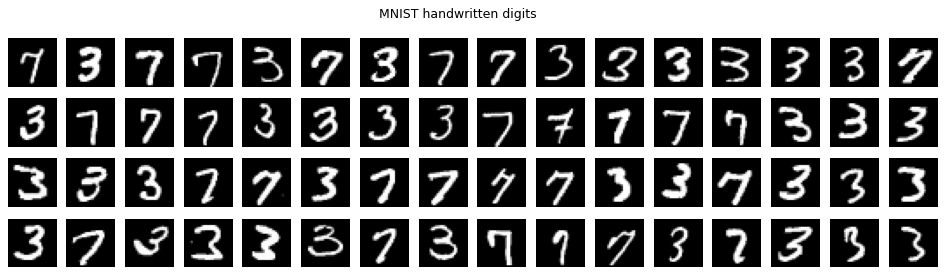

In [3]:
# Flatten the images into a vector
flatten = lambda x: ToTensor()(x).view(28**2)

# Define the train and test sets
dset_train = MNIST("./", train=True,  transform=flatten, download=True)
dset_test  = MNIST("./", train=False, transform=flatten)

# The digit classes to use
classes = [3, 7]

def stratified_sampler(labels):
    """Sampler that only picks datapoints corresponding to the specified classes"""
    (indices,) = np.where(reduce(lambda x, y: x | y, [labels.numpy() == i for i in classes]))
    indices = torch.from_numpy(indices)
    return SubsetRandomSampler(indices)


batch_size = 64
# The loaders perform the actual work
# pin_memory=False to avoid "cannot pin 'torch.cuda.LongTensor'" when tensors are on GPU
train_loader = DataLoader(dset_train, batch_size=batch_size,
                          sampler=stratified_sampler(dset_train.targets), pin_memory=False)
test_loader  = DataLoader(dset_test, batch_size=batch_size,
                          sampler=stratified_sampler(dset_test.targets), pin_memory=False)


#plot a few MNIST examples
f, axarr = plt.subplots(4, 16, figsize=(16, 4))

# Load a batch of images into memory
images, labels = next(iter(train_loader))

for i, ax in enumerate(axarr.flat):
    ax.imshow(images[i].view(28, 28), cmap="binary_r")
    ax.axis('off')

plt.suptitle('MNIST handwritten digits')
plt.show()

## VAE

In [ ]:
import torch.nn as nn
from torch.nn.functional import binary_cross_entropy_with_logits

# define size variables
num_features = 28**2

class MNISTVAE(nn.Module):
    def __init__(self, latent_features, num_samples):
        super().__init__()

        self.num_samples = num_samples
        self.latent_features = latent_features

        # We encode the data onto the latent space using two linear layers
        self.encoder = nn.Sequential(
            nn.Linear(in_features=num_features, out_features=256),
            nn.ReLU(),
            nn.Linear(in_features=256, out_features=128),
            nn.ReLU(),
            # A Gaussian is fully characterised by its mean and variance
            nn.Linear(in_features=128, out_features=2*self.latent_features) # <- note the 2*latent_features
        )

        # The latent code must be decoded into the original image
        self.decoder = nn.Sequential(
            nn.Linear(in_features=self.latent_features, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=256),
            nn.ReLU(),
            nn.Linear(in_features=256, out_features=num_features)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        batch_size = mu.size(0)
        with torch.no_grad():
            eps = torch.randn(batch_size, self.num_samples, self.latent_features, device=mu.device, dtype=mu.dtype)
        return mu.unsqueeze(1) + eps * std.unsqueeze(1)
    
    def encode(self, x):
        mu, logvar = torch.chunk(self.encoder(x), 2, dim=-1)
        z = self.reparameterize(mu, logvar)
        return mu, logvar, z

    def decode(self, z):
        x_hat = self.decoder(z)
        return x_hat

    def forward(self, x):
        mu, logvar, z = self.encode(x)        
        x_hat = self.decode(z)
        return x_hat, mu, logvar, z


def vae_loss(x, x_hat, mu, logvar, beta=1):
    B, S, D = x_hat.shape
    x = x.unsqueeze(1).expand(-1, S, -1)
    recon = binary_cross_entropy_with_logits(x_hat, x, reduction="none").sum(dim=2).mean(dim=1)
    kl = 0.5 * (logvar.exp() + mu.pow(2) - 1 - logvar).sum(dim=1)
    return (recon + beta * kl).mean(), recon.mean(), kl.mean()

In [5]:
# One Forward Pass
num_samples = 10
model = MNISTVAE(2, num_samples).to(device=device, dtype=dtype)
print(model)

X, _ = next(iter(train_loader))
X = X.to(device=device, dtype=dtype)
X_hat, mu, logvar, z = model(X)
print(X_hat.shape, mu.shape, logvar.shape, z.shape)

loss, recon, kl = vae_loss(X, X_hat, mu, logvar)
print(loss.item(), recon.item(), kl.item())


MNISTVAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
  )
)
torch.Size([64, 10, 784]) torch.Size([64, 2]) torch.Size([64, 2]) torch.Size([64, 10, 2])
545.0864868164062 545.0789794921875 0.007549138739705086


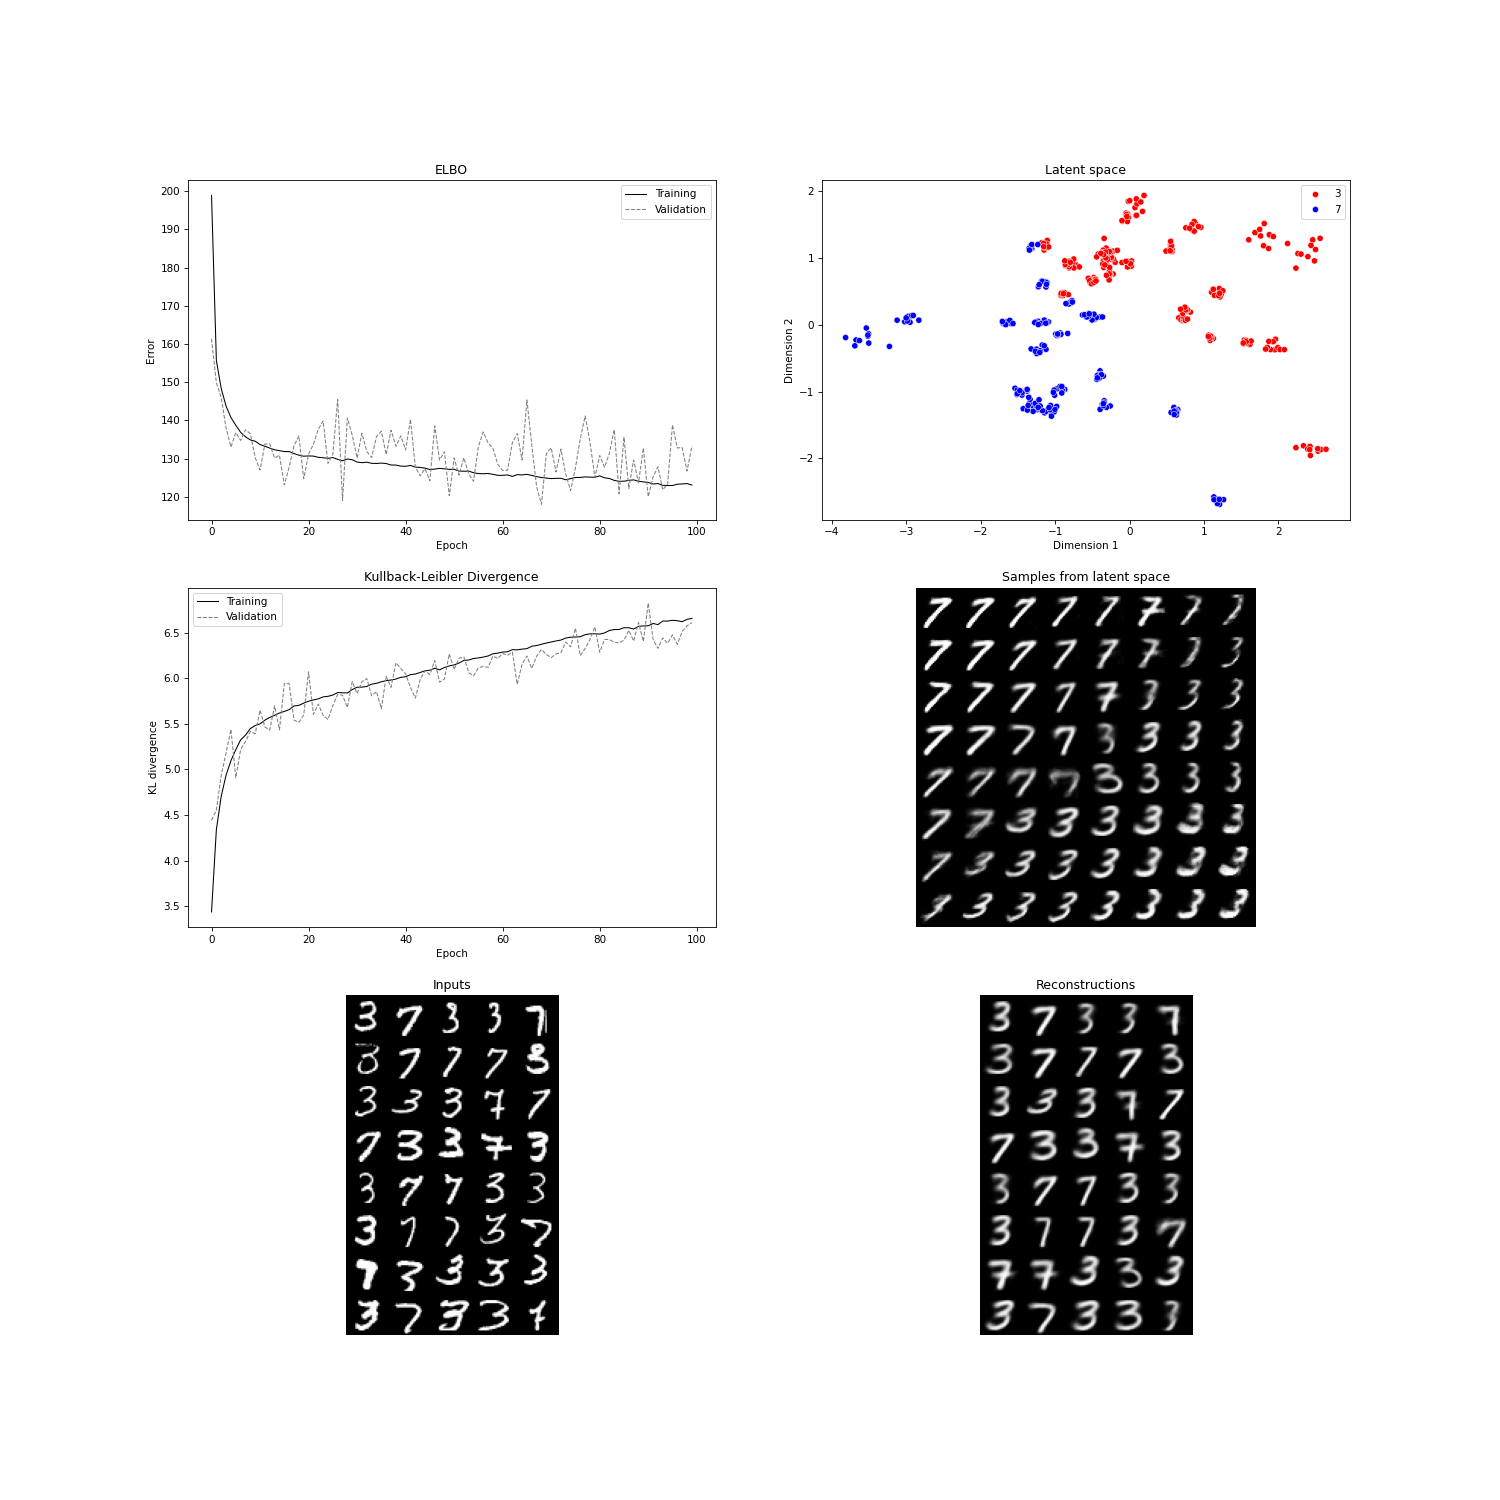

In [10]:
from IPython.display import Image, display, clear_output
deterministic()

# latent_dim=2 for 2D latent space (decoder expects 2D input for grid visualization)
latent_dim = 2
num_samples = 10
beta = 1

tmp_img = "tmp_vae_out2.png"
model = MNISTVAE(latent_dim, num_samples).to(device=device, dtype=dtype)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

train_loss, valid_loss = [], []
train_kl, valid_kl = [], []

for epoch in range(100):
    batch_loss, batch_kl = [], []
    model.train()

    # Go through each batch in the training dataset using the loader
    # Note that y is not necessarily known as it is here
    for x_train, y_train in train_loader:
        x_train = x_train.to(device=device, dtype=dtype)
        x_train_hat, mu, logvar, z_train = model(x_train)
        elbo, recon, kl = vae_loss(x_train, x_train_hat, mu, logvar, beta=beta)

        opt.zero_grad()
        elbo.backward()
        opt.step()

        batch_loss.append(elbo.item())
        batch_kl.append(kl.item())

    train_loss.append(np.mean(batch_loss))
    train_kl.append(np.mean(batch_kl))


    # Evaluate, do not propagate gradients
    with torch.no_grad():
        model.eval()
        # Just load a single batch from the test loader
        x_val, y_val = next(iter(test_loader))
        x_val = x_val.to(device, dtype=dtype)
        x_val_hat, mu, logvar, z_val = model(x_val)

        elbo, recon, kl = vae_loss(x_val, x_val_hat, mu, logvar)

        # We save the latent variable and reconstruction for later use
        # we will need them on the CPU to plot
        y_val = y_val.detach().to("cpu").numpy()
        z_val = z_val.detach().to("cpu").numpy()

        valid_loss.append(elbo.item())
        valid_kl.append(kl.item())

    if epoch == 0:
        continue

    # -- Plotting --
    f, axarr = plt.subplots(3, 2, figsize=(20, 20))

    # ELBO Loss
    ax = axarr[0, 0]
    ax.set_title("ELBO")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Error')
    ax.plot(np.arange(epoch+1), train_loss, color="black")
    ax.plot(np.arange(epoch+1), valid_loss, color="gray", linestyle="--")
    ax.legend(['Training', 'Validation'])

    # KL Loss
    ax = axarr[1, 0]
    ax.set_title("Kullback-Leibler Divergence")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('KL divergence')
    ax.plot(np.arange(epoch+1), train_kl, color="black")
    ax.plot(np.arange(epoch+1), valid_kl, color="gray", linestyle="--")
    ax.legend(['Training', 'Validation'])


    # Latent space scatter plot
    ax = axarr[0, 1]
    # z_flat = z_val.reshape(-1, 2)

    z_flat, z_mean, std_dev = z_create(x_train, model.encode)
    z_flat = z_flat.detach().cpu().numpy()
    
    y_rep = np.repeat(y_train.cpu().numpy(), num_samples)
    zdf = pd.DataFrame(z_flat, columns=["z{}".format(i+1) for i in range(z_flat.shape[1])])
    zdf['label'] = y_rep
    
    sns.scatterplot(data=zdf, x="z1", y="z2", hue="label", ax=ax, palette={3: "red", 7: "blue"},)
    ax.legend()
    ax.set_title('Latent space')
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')


    # Latent space samples image plotting
    rows = 8
    columns = batch_size // rows
    span = np.linspace(-4, 4, rows)
    grid = np.dstack(np.meshgrid(span, span)).reshape(-1, 2)
    ax = axarr[1, 1]
    ax.set_title('Samples from latent space')
    ax.axis('off')
    with torch.no_grad():
        epsilon = torch.from_numpy(grid).float().to(device)
        samples = torch.sigmoid(model.decoder(epsilon)).cpu().detach().numpy()
    canvas = np.zeros((28*rows, columns*28))
    for i in range(rows):
        for j in range(columns):
            idx = i * columns + j
            canvas[i*28:(i+1)*28, j*28:(j+1)*28] = samples[idx].reshape((28, 28))
    ax.imshow(canvas, cmap='gray')


    # Input image plotting (use actual batch size; last batch may be smaller than batch_size)
    x_input = x_train.detach().cpu().numpy()
    n_show = x_input.shape[0]
    rows_show, columns_show = 8, n_show // 8
    ax = axarr[2, 0]
    ax.set_title('Inputs')
    ax.axis('off')
    canvas = np.zeros((28*rows_show, columns_show*28))
    for i in range(rows_show):
        for j in range(columns_show):
            idx = i * columns_show + j
            canvas[i*28:(i+1)*28, j*28:(j+1)*28] = x_input[idx].reshape((28, 28))
    ax.imshow(canvas, cmap='gray')

    
    # Reconstructions image plotting
    x_hat = torch.sigmoid(x_train_hat.mean(dim=1))
    x_hat = x_hat.detach().cpu().numpy()   
    ax = axarr[2, 1]
    ax.set_title('Reconstructions')
    ax.axis('off')
    canvas = np.zeros((28*rows_show, columns_show*28))
    for i in range(rows_show):
        for j in range(columns_show):
            idx = i * columns_show + j
            canvas[i*28:(i+1)*28, j*28:(j+1)*28] = x_hat[idx].reshape((28, 28))
    ax.imshow(canvas, cmap='gray')
    
    plt.savefig(tmp_img)
    plt.close(f)
    display(Image(filename=tmp_img))
    clear_output(wait=True)
    os.remove(tmp_img)
    

<Axes: >

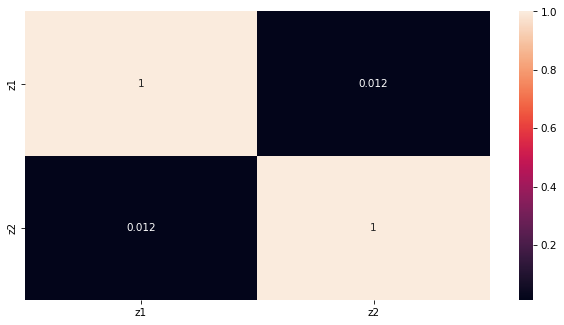

In [8]:
# Select only numeric columns
sns.heatmap(zdf[['z1','z2']].corr(), annot=True)